In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize
import skimage
from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px
import warnings
import ipycanvas
warnings.filterwarnings('ignore')

### Synthetic Data Generation + Processing

Loading kidney data set from skimage

In [2]:
kidney = skimage.data.kidney()

In [3]:
z_planes = np.arange(1,16,2)
slices = [kidney[z] for z in z_planes]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [26..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [62..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [66..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [63..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [37..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [16..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for 

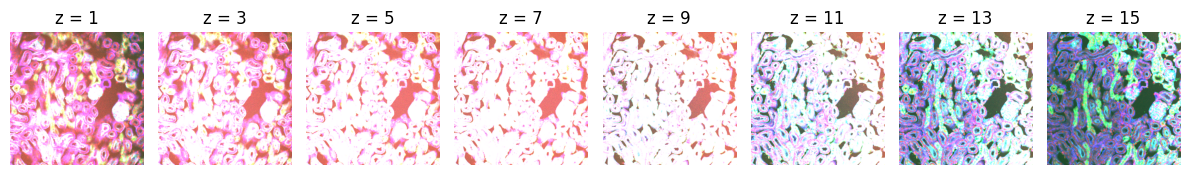

In [4]:
%matplotlib inline
fig, axes = plt.subplots(1, len(z_planes), figsize=(12, 4))

for ax, z in zip(axes, z_planes):
    img = kidney[z]  # shape: (y, x, 3)
    ax.imshow(img)
    ax.set_title(f"z = {z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10..4095].


fixed image shape: (512, 512, 3)


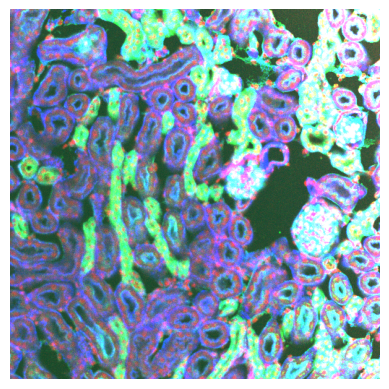

In [5]:
fixed_img = kidney[15]
print(f'fixed image shape: {fixed_img.shape}')
plt.imshow(fixed_img)
plt.axis('off')
plt.show()

In [6]:
import cv2

def crop_with_gui(image_path, offset=(0, 0)):
    img = cv2.imread(image_path)
    clone = img.copy()

    cropping = False
    start = None
    end = None
    rect_final = None

    def mouse(event, x, y, flags, param):
        nonlocal start, end, cropping, img, rect_final

        if event == cv2.EVENT_LBUTTONDOWN:
            start = (x, y)
            cropping = True

        elif event == cv2.EVENT_MOUSEMOVE and cropping:
            img = clone.copy()
            cv2.rectangle(img, start, (x, y), (0, 255, 0), 2)

        elif event == cv2.EVENT_LBUTTONUP:
            end = (x, y)
            cropping = False
            rect_final = (start[0], start[1], end[0], end[1])
            cv2.rectangle(img, start, end, (0, 255, 0), 2)

    cv2.namedWindow("Cropper")
    cv2.setMouseCallback("Cropper", mouse)

    while True:
        cv2.imshow("Cropper", img)
        key = cv2.waitKey(1)

        if key == 13 and rect_final is not None:  # ENTER
            x1, y1, x2, y2 = rect_final
            # Compute min/max
            x_min = min(x1, x2)
            x_max = max(x1, x2)
            y_min = min(y1, y2)
            y_max = max(y1, y2)

            # Local bbox always starts at 0,0
            bbox_local = (0, 0, x_max - x_min, y_max - y_min)

            # Global bbox uses offset
            ox, oy = offset
            bbox_global = (x_min + ox, y_min + oy, x_max + ox, y_max + oy)

            # Cropped image
            cropped = clone[y_min:y_max, x_min:x_max]


            cv2.destroyAllWindows()
            return cropped, bbox_local, bbox_global

        if key == ord("q"):
            cv2.destroyAllWindows()
            return None, None, None, None
cropped, bbox_local, bbox_global= crop_with_gui('/home/kia/justus_kidney.png')

QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

In [7]:
# I want to plot the global bounding box. 
print(bbox_global)
print(bbox_local)

(268, 156, 509, 333)
(0, 0, 241, 177)


In [8]:
import plotly.graph_objects as go
import skimage.io as skio
import plotly.io as pio
pio.renderers.default = "browser"

img = skio.imread("/home/kia/justus_kidney.png")
def plot_bbox_plotly(image, bbox):
    x_min, y_min, x_max, y_max = bbox

    fig = go.Figure()

    # Add the image
    fig.add_trace(go.Image(z=image))

    # Add bounding box as a shape
    fig.update_layout(
        shapes=[
            dict(
                type="rect",
                x0=x_min, y0=y_min,
                x1=x_max, y1=y_max,
                line=dict(color="red", width=3),
                fillcolor="rgba(0,0,0,0)"
            )
        ]
    )

    # Flip y-axis to match image coordinates
    fig.update_yaxes(autorange="reversed")

    fig.update_layout(
        width=image.shape[1],
        height=image.shape[0],
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [15..4095].


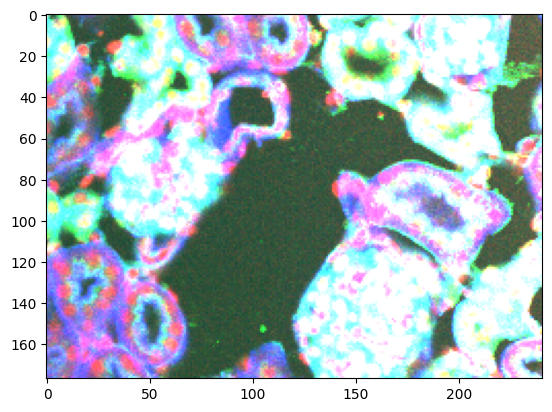

In [9]:
# attempting to crop the region for the rest of the stack 
x_min, y_min, x_max, y_max = bbox_global
fake_maldi = kidney[:, y_min:y_max, x_min:x_max, :]
plt.imshow(fake_maldi[14])

Double checking if the fake maldi data matches the cropped region 

In [10]:
x_min, y_min, x_max, y_max = bbox_global
print("bbox_global =", bbox_global)
print("Width =", x_max - x_min)
print("Height =", y_max - y_min)
plot_bbox_plotly(kidney[1], bbox_global)
plot_bbox_plotly(fake_maldi[1], (0, 0, fake_maldi.shape[2], fake_maldi.shape[1]))


bbox_global = (268, 156, 509, 333)
Width = 241
Height = 177


Now need to make the resolution on the fake MALDI twice as coarse (setting up a simple example)

In [11]:
import numpy as np
from skimage.transform import resize

# 2. Convert entire ROI stack to grayscale in one vectorized call
fake_maldi_gray = rgb2gray(fake_maldi).astype(np.float32)   # shape: (Z, H_roi, W_roi)

# 3. Normalize each plane independently (vectorized)
min_vals = fake_maldi_gray.min(axis=(1,2), keepdims=True)
max_vals = fake_maldi_gray.max(axis=(1,2), keepdims=True)
fake_maldi_gray = (fake_maldi_gray - min_vals) / (max_vals - min_vals + 1e-8)

# 4. Compute target MALDI resolution
target_shape = (fake_maldi_gray.shape[1] // 2, fake_maldi_gray.shape[2] // 2)

# 5. Resize all planes in a loop (cannot vectorize resize)
resized_planes = [
    resize(fake_maldi_gray[z], target_shape, anti_aliasing=True, preserve_range=True).astype(np.float32)
    for z in range(fake_maldi_gray.shape[0])
]

# 6. Stack into a proper MALDI cube (Z, H, W)
resized_maldi_stack = np.stack(resized_planes, axis=0)
resized_maldi_stack.shape # resampled 

(16, 88, 120)

after grey scale they all have the same intensities.....which I don't mind but now we need to random permutaions of half the stack 

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# number of "maldi" images

n_col = 4

def plot_maldi_grid(stack, cmap, n_col=4):

    n_row = int(np.ceil(stack.shape[0] / n_col))

    fig = make_subplots(
        rows=n_row,
        cols=n_col,
        horizontal_spacing=0.02,
        vertical_spacing=0.02
    )

    for i in range(stack.shape[0]):
        r = i // n_col + 1 # integer division to figure out which image goes to which row
        c = i % n_col + 1 # modulo division to figure out what is the column position of that same image

        plane = np.squeeze(stack[i])

        fig.add_trace(
            go.Heatmap(
                z=plane,
                colorscale=cmap,
                showscale=False
            ),
            row=r,
            col=c
        )

        fig.update_xaxes(showticklabels=False, row=r, col=c)
        fig.update_yaxes(
            showticklabels=False,
            autorange="reversed",
            row=r,
            col=c
        )

    fig.update_layout(
        width=1800,
        height=300 * n_row,
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

Now we want to do random shuffling and look at the grid again. We only want to random shuffling on part of the stack...thats it 

(4, 88, 120)
(12, 88, 120)


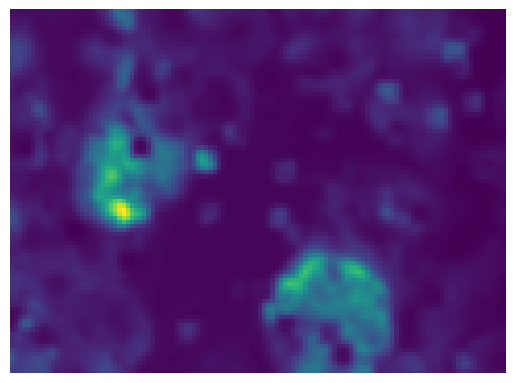

In [13]:
import numpy as np
from scipy.ndimage import gaussian_filter

def shuffle_patches(img, num_patches=8, patch_size=32, sigma=1.0):
    H, W = img.shape
    patches = []
    coords = []

    # 1. Collect random patches
    for _ in range(num_patches):
        y = np.random.randint(0, H - patch_size)
        x = np.random.randint(0, W - patch_size)

        patch = img[y:y+patch_size, x:x+patch_size].copy()
        patches.append(patch)
        coords.append((y, x))

    # 2. Shuffle patch order
    patches = np.array(patches)
    np.random.shuffle(patches)

    # 3. Paste shuffled patches back
    shuffled_img = img.copy()
    for (y, x), patch in zip(coords, patches):
        shuffled_img[y:y+patch_size, x:x+patch_size] = patch

    # 4. Smooth the result
    if sigma > 0:
        shuffled_img = gaussian_filter(shuffled_img, sigma=sigma)

    return shuffled_img
num_rand_shuffle_img = 4
rand_split_maldi = resized_maldi_stack[:num_rand_shuffle_img].copy()
norm_split_maldi = resized_maldi_stack[num_rand_shuffle_img:].copy()

# Shuffle patches in each selected plane
for i in range(rand_split_maldi.shape[0]):
    rand_split_maldi[i] = shuffle_patches(
        rand_split_maldi[i],
        num_patches=70,     # number of patches to shuffle
        patch_size=5,       # patch size
        sigma=1             # smoothing strength
    )

# visualize
plt.imshow(rand_split_maldi[1])
plt.axis("off")

# recombine maldi stack 
print(rand_split_maldi.shape)
print(norm_split_maldi.shape)
#full_fake_maldi =  np.concatenate([rand_split_maldi, norm_split_maldi], axis=0)   
#print(full_fake_maldi.shape)

In [14]:
np.random.seed(42)
# combine image stacks 
complete_fake_maldi = np.concatenate([rand_split_maldi, norm_split_maldi], axis=0)

# randomize image order
maldi_img_idx = np.random.permutation(complete_fake_maldi.shape[0])
complete_fake_maldi = complete_fake_maldi[maldi_img_idx]

# confirm whole stack is intact 
complete_fake_maldi.shape

(16, 88, 120)

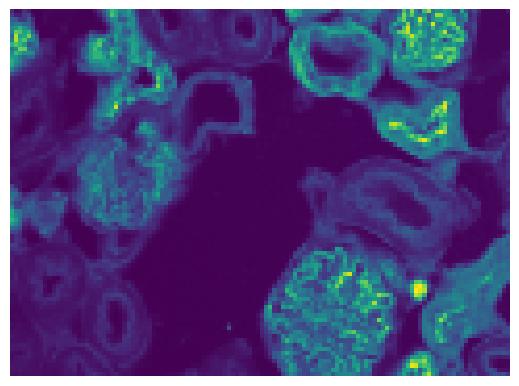

(88, 120)
(512, 512, 3)


In [15]:
fig = plt.figure(frameon=False)
fig.set_size_inches(5, 5)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(complete_fake_maldi[13])

plt.show()
print(complete_fake_maldi[13].shape)
print(kidney[14].shape)

save the maldi image for global alignment

(np.float64(-0.5), np.float64(119.5), np.float64(87.5), np.float64(-0.5))

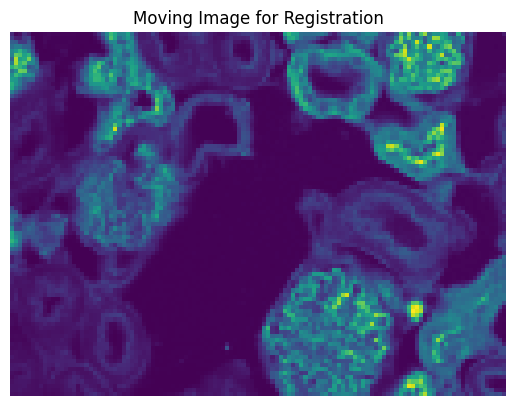

In [16]:
def save_fake_img(img, pic_name, cmap='viridis'):
    plt.figure(frameon=False)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')

    plt.savefig(
        f"/home/kia/MALDI_Metabolomics/kidney_test/{pic_name}.png",
        bbox_inches='tight',
        pad_inches=0
    )
    plt.close()
maldi_img = complete_fake_maldi[13]
pic_name = "maldi_test_img"
save_fake_img(maldi_img, pic_name)
plt.imshow(maldi_img)
plt.title('Moving Image for Registration')
plt.axis('off')

Save the image that is supposed to be our H&E

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

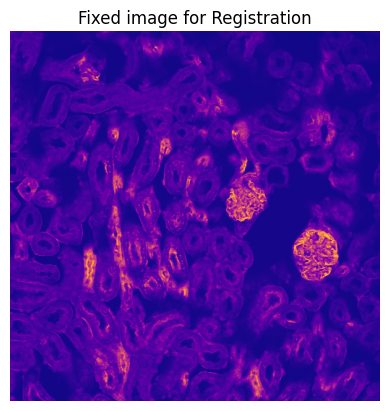

In [17]:
kidney_gray = rgb2gray(kidney).astype(np.float32)
#Normalize each plane independently (vectorized)
min_vals = kidney_gray.min(axis=(1,2), keepdims=True)
max_vals = kidney_gray.max(axis=(1,2), keepdims=True)
kidney_norm = (kidney_gray - min_vals) / (max_vals - min_vals + 1e-8)
plt.imshow(kidney_norm[4], cmap='plasma') # 12 maybe, 11 better, 10 better, 6 seems best 
plt.title('Fixed image for Registration')
plt.axis('off')

In [18]:
he_img = kidney_norm[4]
pic_name = "HE_fake_img"
cmap='plasma'
save_fake_img(he_img, pic_name, cmap)

In [19]:
print(f'original resolution: {img.shape}\nresized resolution: {complete_fake_maldi[13].shape}')

original resolution: (480, 640, 4)
resized resolution: (88, 120)


### SimpleITK registration: Landmark Reg + B-Spline Refinement

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def pick_landmarks_matplotlib(he_image, maldi_image, n_points):
    print(f"\n{'='*60}\nLANDMARK SELECTION -- click {n_points} vessel pairs\n{'='*60}")
    
    if type(he_image) == sitk.Image:
        print('SimpleITK image format...changing to numpy array')
        he_image = sitk.GetArrayFromImage(he_image)
        maldi_image = sitk.GetArrayFromImage(maldi_image) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(he_image);    ax1.set_title("H&E -- FIRST",   fontweight="bold"); ax1.axis("off")
    ax2.imshow(maldi_image); ax2.set_title("MALDI -- SECOND", fontweight="bold"); ax2.axis("off")

    he_pts, maldi_pts, current = [], [], ["he"]

    def onclick(event):
        if event.inaxes is None:
            return
        x, y = event.xdata, event.ydata

        if event.inaxes == ax1 and current[0] == "he":
            if len(he_pts) < n_points:
                he_pts.append([x, y])
                i = len(he_pts)
                ax1.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax1.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"H&E landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(he_pts) == n_points:
                current[0] = "maldi"
                ax2.set_title("MALDI -- CLICK NOW", fontweight="bold", color="red")
                fig.canvas.draw_idle()

        elif event.inaxes == ax2 and current[0] == "maldi":
            if len(maldi_pts) < n_points:
                maldi_pts.append([x, y])
                i = len(maldi_pts)
                ax2.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax2.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"MALDI landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(maldi_pts) == n_points:
                ax2.set_title("MALDI -- COMPLETE! Close window.", fontweight="bold", color="green")
                fig.canvas.mpl_disconnect(cid)
                fig.canvas.draw()
                plt.close(fig)  # unblocks plt.show(block=True)
                return

        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show(block=True)  # blocks here until all landmarks are picked

    print("Landmark selection complete.")
    return np.array(he_pts, dtype=float), np.array(maldi_pts, dtype=float)

In [21]:
""" SimpleITK landmark registration """
%matplotlib tk
import SimpleITK as sitk

# Build sitk images directly from the arrays — no PNG round-trip
fixed_img = sitk.ReadImage('/home/kia/MALDI_Metabolomics/kidney_test/HE_fake_img.png', sitk.sitkFloat32)
fixed_img.SetSpacing([1,1])
fixed_img.SetOrigin([0,0])

moving_image = sitk.ReadImage('/home/kia/MALDI_Metabolomics/kidney_test/maldi_test_img.png', sitk.sitkFloat32)
moving_image.SetSpacing([1,1])
moving_image.SetOrigin([0,0])

# Picker shows the same arrays → clicks are in native pixel coordinates
fixed_landmarks, moving_landmarks = pick_landmarks_matplotlib(fixed_img, moving_image, n_points=4)


# Fit only rotation + translation — scale is already resolved
landmark_initializer = sitk.LandmarkBasedTransformInitializerFilter()
landmark_initializer.SetFixedLandmarks(fixed_landmarks.flatten().tolist())
landmark_initializer.SetMovingLandmarks(moving_landmarks.flatten().tolist())

#transform = sitk.AffineTransform(2) # Affine shearing is too intense for global registration
transform = sitk.AffineTransform(2)

# use only 3 landmark pairs minimum to fit rotation + translation
output_transform = landmark_initializer.Execute(transform)
print(output_transform)

# Resample moving onto fixaed
output_image = sitk.Resample(
    moving_image, fixed_img, transform=output_transform, defaultPixelValue=10
)

#rescaled = sitk.RescaleIntensity(output_image, 0, 255)
#rescaled = sitk.Cast(rescaled, sitk.sitkUInt8)
#sitk.WriteImage(rescaled, "/home/kia/MALDI_Metabolomics/kidney_test/landmark_example.png")


LANDMARK SELECTION -- click 4 vessel pairs
SimpleITK image format...changing to numpy array
H&E landmark 1/4: (195.5, 125.7)
H&E landmark 2/4: (225.7, 204.3)
H&E landmark 3/4: (328.5, 130.4)
H&E landmark 4/4: (334.1, 236.4)
MALDI landmark 1/4: (16.8, 30.2)
MALDI landmark 2/4: (96.7, 253.3)
MALDI landmark 3/4: (391.7, 57.1)
MALDI landmark 4/4: (409.2, 347.0)
Landmark selection complete.
itk::simple::AffineTransform
 AffineTransform (0x63fa9ff11e00)
   RTTI typeinfo:   itk::AffineTransform<double, 2u>
   Reference Count: 1
   Modified Time: 2037
   Debug: Off
   Object Name: 
   Observers: 
     none
   Matrix: 
     2.84711 -0.0163724 
     0.0837187 2.75721 
   Offset: [-540.01, -331.096]
   Center: [0, 0]
   Translation: [-540.01, -331.096]
   Inverse: 
     0.351172 0.00208528 
     -0.0106628 0.362622 
   Singular: 0



Time to visualize the registration on the heatmap plot

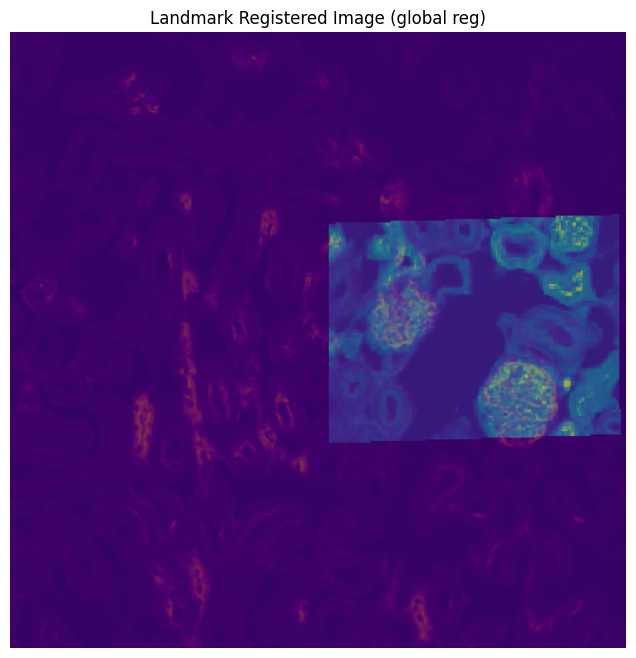

In [22]:
%matplotlib inline
#arr = sitk.GetArrayFromImage(rescaled)
arr_affine = sitk.GetArrayFromImage(output_image)
plt.figure(figsize=(8,8))

plt.imshow(
    sitk.GetArrayFromImage(fixed_img),
    cmap="plasma"
)

plt.imshow(
    arr_affine,
    cmap="viridis",
    alpha=0.7
)
plt.title('Landmark Registered Image (global reg)')
#plt.colorbar()
plt.axis('off')
plt.savefig('/home/kia/MALDI_Metabolomics/kidney_test/affine_transform.png')
plt.show()

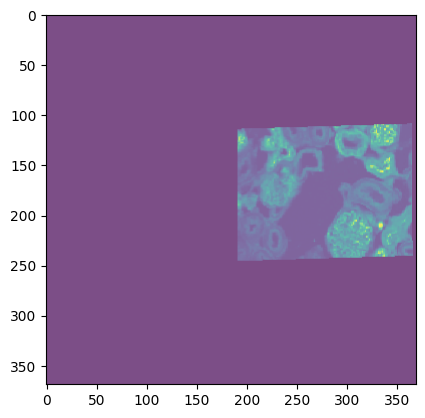

In [23]:
plt.imshow(
    arr_affine,
    cmap="viridis",
    alpha=0.7
)

### Run refinement using B-splines after landmark registration 

In [24]:
# Start from original moving image, not the affine-warped result
composite = sitk.CompositeTransform(2)
composite.AddTransform(output_transform)   # existing affine (fixed→moving)

# B-spline adds fine deformation on top
bspline_tx = sitk.BSplineTransformInitializer(fixed_img, [10, 10])
composite.AddTransform(bspline_tx)

R = sitk.ImageRegistrationMethod()
R.SetMetricAsMattesMutualInformation(50)
R.SetOptimizerAsGradientDescentLineSearch(
    5.0, 100, convergenceMinimumValue=1e-4, convergenceWindowSize=5
)
R.SetOptimizerScalesFromPhysicalShift()
R.SetInitialTransform(composite, inPlace=True)   # optimises only the B-spline DOF
R.SetMovingInitialTransform(sitk.Transform())    # affine already in composite
R.SetInterpolator(sitk.sitkNearestNeighbor)
R.SetShrinkFactorsPerLevel([4, 2, 1])
R.SetSmoothingSigmasPerLevel([4, 2, 1])

outTx = R.Execute(fixed_img, moving_image)   # ← original moving, not output_image

# Apply full composite (affine + B-spline) to original moving
refined_img = sitk.Resample(
    moving_image, fixed_img, transform=outTx, defaultPixelValue=0
)


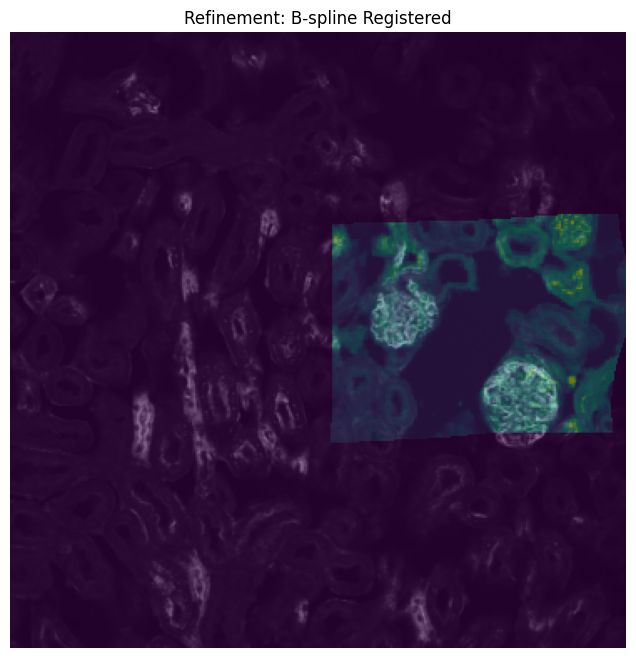

In [25]:
arr = sitk.GetArrayFromImage(refined_img)
plt.figure(figsize=(8,8))

plt.imshow(
    sitk.GetArrayFromImage(fixed_img),
    cmap="grey"
)

plt.imshow(
    arr,
    cmap="viridis",
    alpha=0.5
)
plt.title('Refinement: B-spline Registered')
#plt.colorbar()
plt.axis('off')
plt.savefig('/home/kia/MALDI_Metabolomics/kidney_test/full_B-spline_Reg.png')
plt.show()

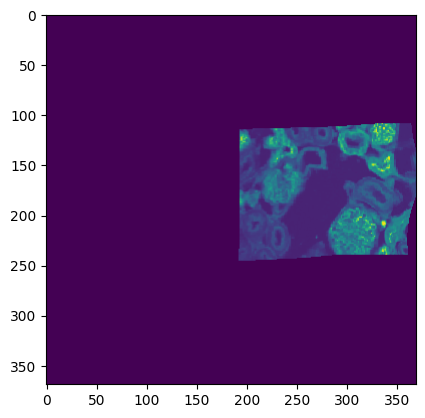

In [26]:
plt.imshow(sitk.GetArrayFromImage(refined_img))

In [27]:
import napari

he_arr    = sitk.GetArrayFromImage(fixed_img)
maldi_arr = sitk.GetArrayFromImage(refined_img)

viewer = napari.Viewer(title="B-spline Registration Overlay")
viewer.add_image(he_arr,    name="H&E",   colormap="grey",    blending="additive")
viewer.add_image(maldi_arr, name="MALDI", colormap="viridis", blending="additive", opacity=0.5)

napari.run()

(369, 369)


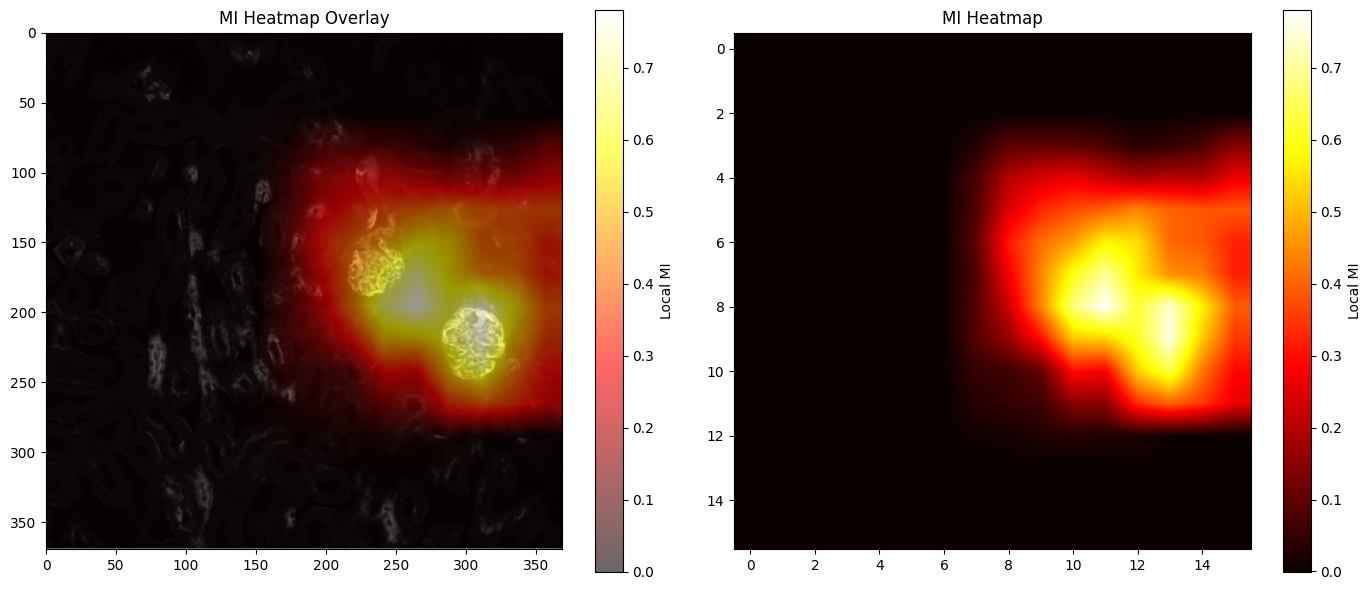

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def local_mi_heatmap(img1, img2, patch_size=32, step=16, n_bins=32):
    """Compute MI between corresponding patches of two registered images."""
    # normalize to [0,1]
    def norm(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
    img1, img2 = norm(img1.astype(float)), norm(img2.astype(float))

    H, W = img1.shape
    row_starts = range(0, H - patch_size, step)
    col_starts = range(0, W - patch_size, step)
    mi_grid = np.zeros((len(row_starts), len(col_starts)))

    for i, r in enumerate(row_starts):
        for j, c in enumerate(col_starts):
            p1 = img1[r:r+patch_size, c:c+patch_size].ravel()
            p2 = img2[r:r+patch_size, c:c+patch_size].ravel()

            hist2d, _, _ = np.histogram2d(p1, p2, bins=n_bins, range=[[0,1],[0,1]])
            hist2d /= hist2d.sum() + 1e-10

            h_x  = entropy(hist2d.sum(axis=1) + 1e-10)
            h_y  = entropy(hist2d.sum(axis=0) + 1e-10)
            h_xy = entropy(hist2d.ravel()     + 1e-10)

            mi_grid[i, j] = h_x + h_y - h_xy

    return mi_grid

he_arr    = sitk.GetArrayFromImage(fixed_img)
maldi_arr = sitk.GetArrayFromImage(refined_img)
print(maldi_arr.shape)
mi_grid = local_mi_heatmap(he_arr, maldi_arr, patch_size=64, step=20)
H,W = he_arr.shape
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overlay on H&E
axes[0].imshow(he_arr, cmap="gray")
im = axes[0].imshow(mi_grid, extent=[0, W, H, 0],
                    cmap="hot", alpha=0.6, interpolation="bilinear",
                    vmin=0)
plt.colorbar(im, ax=axes[0], label="Local MI")
axes[0].set_title("MI Heatmap Overlay")

# Standalone heatmap
im2 = axes[1].imshow(mi_grid, cmap="hot", interpolation="bilinear")
plt.colorbar(im2, ax=axes[1], label="Local MI")
axes[1].set_title("MI Heatmap")

plt.tight_layout()
plt.show()


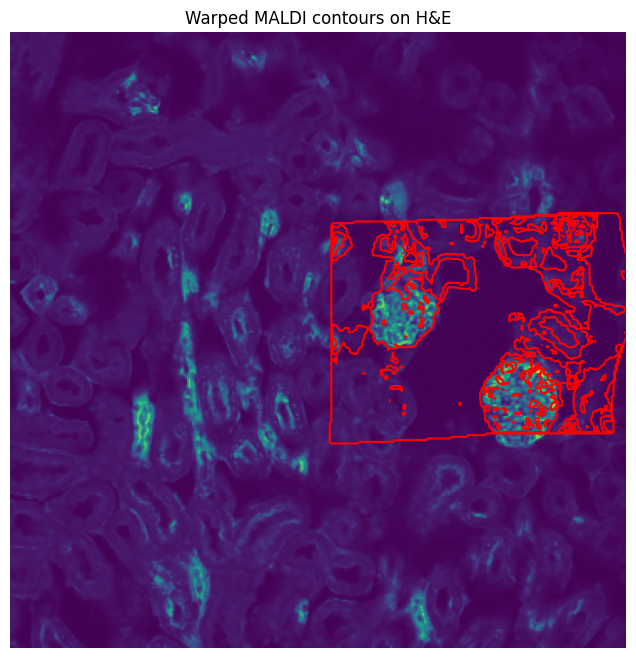

In [29]:
he_arr     = sitk.GetArrayFromImage(fixed_img)
warped_arr = sitk.GetArrayFromImage(refined_img)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(he_arr, cmap="viridis")
#threshold = warped_arr[warped_arr > 0].mean()   # or pick a value manually
ax.contour(warped_arr, levels=3, colors="red", linewidths=1.5)
ax.set_title("Warped MALDI contours on H&E")
plt.axis('off')
plt.savefig('/home/kia/MALDI_Metabolomics/kidney_test/Kidney_registration_contours.png')
plt.show()


### ANTsPy registration: Geometry Based First (mask alignment)

In [30]:
# All pixel coordinates
rows, cols = np.indices(complete_fake_maldi[0].shape[:2])

n_planes, H, W = complete_fake_maldi.shape

# Reshape: (n_planes, H*W) → transpose → (H*W, n_planes)
X = complete_fake_maldi.reshape(n_planes, -1).T

First build the structural masks 

In [31]:
cols # is a grid but not N^2  coords

array([[  0,   1,   2, ..., 117, 118, 119],
       [  0,   1,   2, ..., 117, 118, 119],
       [  0,   1,   2, ..., 117, 118, 119],
       ...,
       [  0,   1,   2, ..., 117, 118, 119],
       [  0,   1,   2, ..., 117, 118, 119],
       [  0,   1,   2, ..., 117, 118, 119]], shape=(88, 120))

Testing PCA vs NMF compnents based on structural features

In [32]:
from sklearn.decomposition import PCA

# we will build the MALDI mask geometrically (find geometry via dimensional reduction)
n_components = 5
model = PCA(n_components=n_components, random_state=42)
W_mat = model.fit_transform(X)

# Build per-component images, normalize each to [0, 1]
# This is building the components into images, can be plotted by plt.imshow(comp_imgs[k], cmap="viridis")
pca_imgs = np.zeros((n_components, H, W), dtype=np.float32)
for k in range(n_components):
    c = W_mat[:, k]
    c = c / (c.max() + 1e-8)
    pca_imgs[k] = c.reshape(H, W) # need to reshape the the scores to fit the grid in comp. imgs
plot_maldi_grid(pca_imgs, n_col=3)

In [33]:
model = NMF(n_components=n_components, init="nndsvda",
            max_iter=500, random_state=42)
W_nmf = model.fit_transform(X)

# Build per-component images, normalize each to [0, 1]
# This is building the components into images, can be plotted by plt.imshow(comp_imgs[k], cmap="viridis")
nmf_imgs = np.zeros((n_components, H, W), dtype=np.float32)
for k in range(n_components):
    c = W_nmf[:, k]
    c = c / (c.max() + 1e-8)
    nmf_imgs[k] = c.reshape(H, W)
plot_maldi_grid(nmf_imgs, n_col=4)

Based on the grids it looks like NMF components do better than PCA components in terms of structure

In [43]:
# Looking at what the vessel filters look like per component
from skimage.filters import frangi
frangi_comps = np.array([frangi(img) for img in nmf_imgs])
plot_maldi_grid(frangi_comps, cmap='gray')

In [ ]:
# looking at the edge maps per component
from skimage.filters import sobel
edge_comps = np.array([sobel(img) for img in nmf_imgs]) # using sobel filter for edge maps
plot_maldi_grid(edge_comps, cmap='gray')

In [50]:
# structure tensor / structure coherence 
anisotropy_comp = []

for img in nmf_imgs:
    Axx, Axy, Ayy = structure_tensor(img, sigma=2)
    trace = Axx + Ayy
    det_term = np.sqrt(np.maximum((Axx - Ayy) ** 2 + 4.0 * Axy ** 2, 0.0))
    lambda1 = 0.5 * (trace + det_term)
    lambda2 = 0.5 * (trace - det_term)
    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)
    anisotropy_comp.append(anisotropy)
plot_maldi_grid(np.array(anisotropy_comp), cmap='Spectral')   
# we will not use this either 

(np.float64(-0.5), np.float64(119.5), np.float64(87.5), np.float64(-0.5))

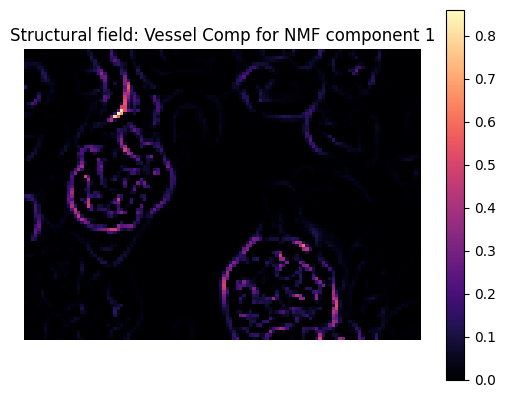

In [59]:
def compute_structural_fields(img: np.ndarray) -> dict: 
    ''' Combing all feature maps into a structural field tensor'''
    
    # edge map 
    edge_map = sobel(img)

    # vessels
    vessel_filter = frangi(img)
    return {'edge' : edge_map, 'vessels': vessel_filter}

# each image has structural features 
component_fields = [
        compute_structural_fields(nmf_imgs[k])
        for k in range(n_components)
    ]
plt.imshow(component_fields[0]["vessels"], cmap="magma")
plt.colorbar()
plt.title("Structural field: Vessel Comp for NMF component 1")
plt.axis("off")

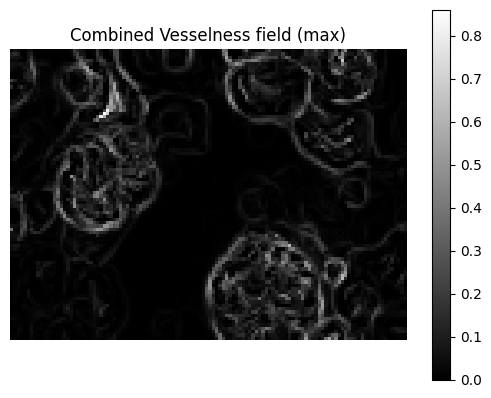

dict_keys(['edge', 'vessels'])


In [65]:
def combine_component_structural_fields(component_fields: list) -> dict:
    """Combine per-component structural fields without averaging intensities."""

    # combine the component fields into 1 stack per feature
    edge_stack = np.stack([f["edge"] for f in component_fields], axis=0)
    vessel_stack = np.stack([f["vessels"] for f in component_fields], axis=0)

    # grabbing the max from the stack of structural features
    edge = edge_stack.max(axis=0)
    vesselness = vessel_stack.max(axis=0)


    return {
        "edge": edge,
        "vessels": vesselness
    }

structural_combine = "max" # or "weighted_mean"
structural_fields = combine_component_structural_fields(component_fields)
plt.imshow(structural_fields["vessels"], cmap="gray")
plt.colorbar()
plt.title(f"Combined Vesselness field ({structural_combine})")
plt.axis("off")
plt.show()
print(structural_fields.keys())